In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Path to the FDI detection dataset directory
dataset_dir = Path('../data/fdi_Detection/Big_Datasets_for_Intelligent_Anomaly_Detection_Mi')

print(f"Scanning directory: {dataset_dir.resolve()}")
csv_files = sorted(list(dataset_dir.glob('*.csv')))

print(f"\nFound {len(csv_files)} CSV files in dataset folder:")
for i, f in enumerate(csv_files, 1):
    file_size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  [{i}] {f.name} ({file_size_mb:.2f} MB)")

Scanning directory: C:\Users\waliu\OneDrive\Documents\Code\Projects\Thesis\data\fdi_Detection\Big_Datasets_for_Intelligent_Anomaly_Detection_Mi

Found 15 CSV files in dataset folder:
  [1] 1(b) current_timeseries_data_normal-fFZRUl.csv (0.55 MB)
  [2] 1(c) current and voltage_timeseries_data_normal-Cvp9gI.csv (2.05 MB)
  [3] 2(a) voltage_timeseries_data_with_anomalies.csv (0.55 MB)
  [4] 2(b) current_timeseries_data_with_anomalies.csv (0.55 MB)
  [5] 2(c) current and voltage_timeseries_big_all_with_anomalies.csv (2.54 MB)
  [6] 2(d) frequency_timeseries_data_with_anomalies.csv (0.55 MB)
  [7] 3(a) random_forecast_D_30d_1h_current.csv (0.27 MB)
  [8] 3(b) random_forecast_D_30d_1h_frequency.csv (0.27 MB)
  [9] 3(c) random_forecast_D_30d_1h_voltage.csv (0.28 MB)
  [10] 3(d) random_forecast_H_24h_10min_current.csv (0.05 MB)
  [11] 3(e) random_forecast_H_24h_10min_frequency.csv (0.06 MB)
  [12] 3(f) random_forecast_H_24h_10min_voltage.csv (0.06 MB)
  [13] 3(g) random_forecast_Y_365d_6h_curr

In [2]:
# Primary telemetry file used for downstream multi-feeder FDI detection
target_csv = dataset_dir / "2(c) current and voltage_timeseries_big_all_with_anomalies.csv"
assert target_csv.exists(), f"Target file not found: {target_csv}"

# Read head sample
df_preview = pd.read_csv(target_csv, nrows=100)

print(f"\n--- Schema Overview for: {target_csv.name} ---")
print(f"Total Column Count: {len(df_preview.columns)}")
print("\nAll Available Column Names:")
for col in df_preview.columns:
    print(f"  • {col}")

print("\n--- Data Sample (First 5 Rows) ---")
display(df_preview.head())


--- Schema Overview for: 2(c) current and voltage_timeseries_big_all_with_anomalies.csv ---
Total Column Count: 8

All Available Column Names:
  • time_s
  • feeder
  • voltage_kV
  • current_A
  • frequency_Hz
  • is_anomaly_voltage
  • is_anomaly_current
  • is_anomaly_frequency

--- Data Sample (First 5 Rows) ---


,time_s,feeder,voltage_kV,current_A,frequency_Hz,is_anomaly_voltage,is_anomaly_current,is_anomaly_frequency
0,0.0,3 kV Feeder,3.006911,121.872511,50.030449,False,False,False
1,0.0,5 kV Feeder,5.040968,108.474117,50.047722,False,False,False
2,0.0,8 kV Feeder,8.043861,83.927950,50.027751,False,False,False
3,0.0,12 kV Feeder,12.045215,65.432395,50.016963,False,False,False
4,0.5,3 kV Feeder,3.017087,123.635813,50.041327,False,False,False


In [4]:
# Cell 3 (Fixed): Robust Physical Measurements & Anomaly Class Distribution Analysis

print("Loading complete dataset for statistical profiling...")
df_full = pd.read_csv(target_csv)

print(f"\nTotal Recorded Rows:    {len(df_full):,}")
print(f"Memory Usage:           {df_full.memory_usage().sum() / (1024*1024):.2f} MB")
print(f"Total Null Values:      {df_full.isnull().sum().sum()}")

# Separate columns into Anomaly Labels, Numeric Sensor Telemetry, and Metadata/Categorical
anomaly_cols = [c for c in df_full.columns if any(k in c.lower() for k in ['anomaly', 'label', 'attack', 'target', 'class'])]
non_anomaly_cols = [c for c in df_full.columns if c not in anomaly_cols]

numeric_telemetry_cols = []
meta_cols = []

for c in non_anomaly_cols:
    if pd.api.types.is_numeric_dtype(df_full[c]):
        numeric_telemetry_cols.append(c)
    else:
        meta_cols.append(c)

print(f"\n--- Metadata / Categorical Columns ({len(meta_cols)}) ---")
for c in meta_cols:
    unique_vals = df_full[c].dropna().unique()
    preview = list(unique_vals[:5])
    print(f"  • {c:<25} | Distinct: {len(unique_vals):<5} | Preview: {preview}")

print(f"\n--- Continuous Physical Telemetry Measurements ({len(numeric_telemetry_cols)}) ---")
for c in numeric_telemetry_cols:
    vals = df_full[c].dropna()
    print(f"  • {c:<25} | Min: {vals.min():10.4f} | Max: {vals.max():10.4f} | Mean: {vals.mean():10.4f} | Std: {vals.std():10.4f}")

print(f"\n--- Ground Truth Anomaly / Attack Columns ({len(anomaly_cols)}) ---")
for c in anomaly_cols:
    val_counts = df_full[c].value_counts(dropna=False).to_dict()
    print(f"  • {c:<25} | Value Counts: {val_counts}")

Loading complete dataset for statistical profiling...

Total Recorded Rows:    28,804
Memory Usage:           1.18 MB
Total Null Values:      0

--- Metadata / Categorical Columns (1) ---
  • feeder                    | Distinct: 4     | Preview: ['3 kV Feeder', '5 kV Feeder', '8 kV Feeder', '12 kV Feeder']

--- Continuous Physical Telemetry Measurements (4) ---
  • time_s                    | Min:     0.0000 | Max:  3600.0000 | Mean:  1800.0000 | Std:  1039.3929
  • voltage_kV                | Min:     2.7430 | Max:    13.1111 | Mean:     6.9999 | Std:     3.3914
  • current_A                 | Min:    43.4585 | Max:   160.2742 | Mean:    87.3840 | Std:    22.5501
  • frequency_Hz              | Min:    49.7491 | Max:    50.2687 | Mean:    49.9999 | Std:     0.0273

--- Ground Truth Anomaly / Attack Columns (3) ---
  • is_anomaly_voltage        | Value Counts: {False: 28780, True: 24}
  • is_anomaly_current        | Value Counts: {False: 28772, True: 32}
  • is_anomaly_frequency      

Sanitized Columns in df_clean: ['time_s', 'feeder', 'voltage_kV', 'current_A', 'frequency_Hz', 'is_anomaly_voltage', 'is_anomaly_current', 'is_anomaly_frequency']
Selected Sensors: Voltage='voltage_kV', Current='current_A'
Selected Labels:  'is_anomaly_voltage', 'is_anomaly_current', 'is_anomaly_frequency'


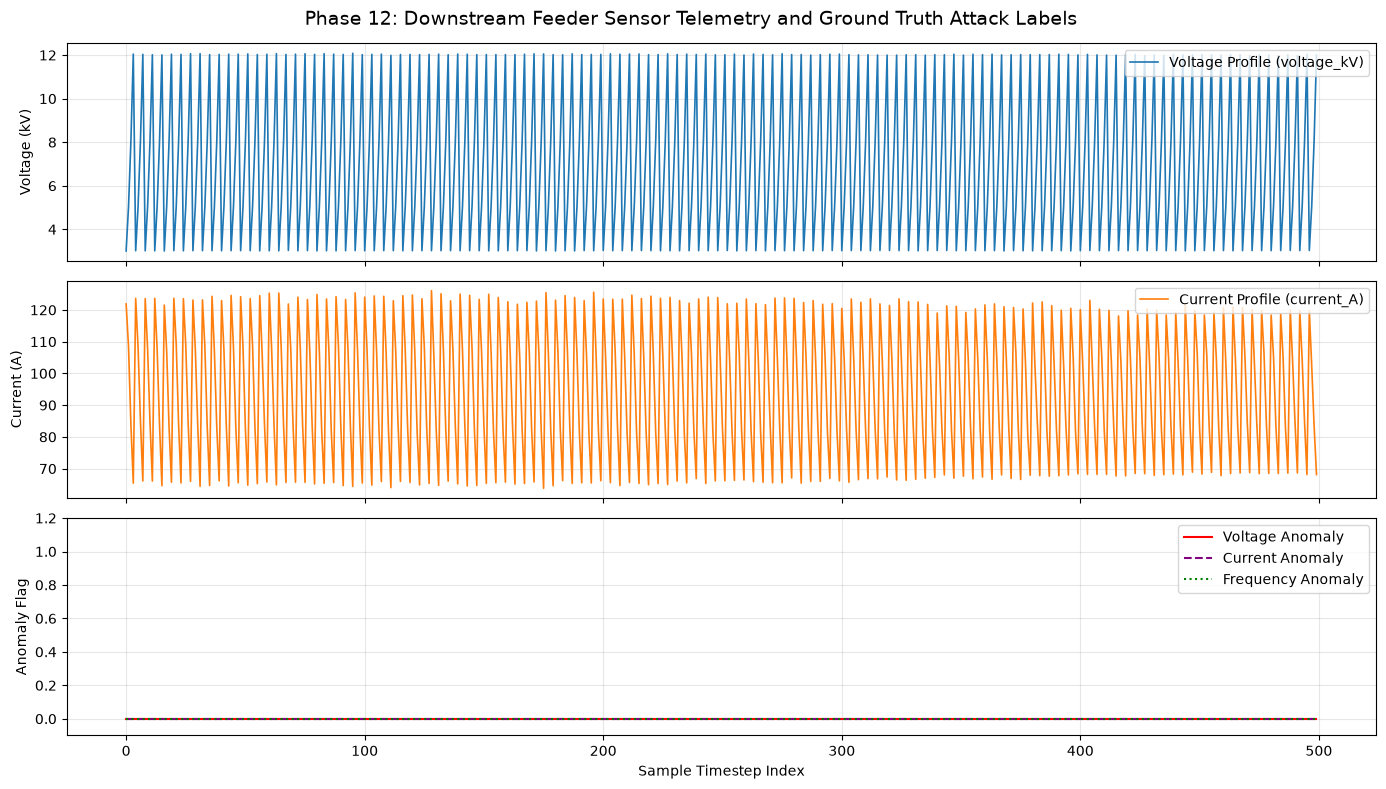

In [9]:
# Cell 4 (Robust Column Cleaning): Multi-Sensor Feeder Distribution Visualization
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# 1. Clean column headers: remove '#' and whitespace
df_clean = df_full.copy()
df_clean.columns = df_clean.columns.str.replace('#', '', regex=False).str.strip()

print("Sanitized Columns in df_clean:", list(df_clean.columns))

# 2. Dynamically pick exact matches
v_col = [c for c in df_clean.columns if 'voltage' in c.lower() and 'anomaly' not in c.lower()][0]
i_col = [c for c in df_clean.columns if 'current' in c.lower() and 'anomaly' not in c.lower()][0]

v_anom = [c for c in df_clean.columns if 'anomaly_voltage' in c.lower() or ('voltage' in c.lower() and 'anomaly' in c.lower())][0]
i_anom = [c for c in df_clean.columns if 'anomaly_current' in c.lower() or ('current' in c.lower() and 'anomaly' in c.lower())][0]
f_anom = [c for c in df_clean.columns if 'anomaly_frequency' in c.lower() or ('freq' in c.lower() and 'anomaly' in c.lower())][0]

print(f"Selected Sensors: Voltage='{v_col}', Current='{i_col}'")
print(f"Selected Labels:  '{v_anom}', '{i_anom}', '{f_anom}'")

# 3. Select first 500 timesteps to inspect waveforms
subset = df_clean.iloc[:500]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Subplot 1: Voltage Profile
axes[0].plot(subset[v_col], color='#1f77b4', lw=1.2, label=f'Voltage Profile ({v_col})')
axes[0].set_ylabel('Voltage (kV)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Subplot 2: Current Profile
axes[1].plot(subset[i_col], color='#ff7f0e', lw=1.2, label=f'Current Profile ({i_col})')
axes[1].set_ylabel('Current (A)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Subplot 3: Anomaly Flags
axes[2].plot(subset[v_anom].astype(int), label='Voltage Anomaly', color='red', lw=1.5)
axes[2].plot(subset[i_anom].astype(int), label='Current Anomaly', color='purple', lw=1.5, linestyle='--')
axes[2].plot(subset[f_anom].astype(int), label='Frequency Anomaly', color='green', lw=1.5, linestyle=':')
axes[2].set_ylabel('Anomaly Flag')
axes[2].set_ylim(-0.1, 1.2)
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

axes[2].set_xlabel('Sample Timestep Index')
plt.suptitle('Phase 12: Downstream Feeder Sensor Telemetry and Ground Truth Attack Labels', fontsize=14)
plt.tight_layout()
plt.savefig(fig_dir / 'phase12_feeder_telemetry_inspection.png', dpi=300)
plt.show()